<a href="https://colab.research.google.com/github/ahmed-zunaira/APS360_Project/blob/main/notebooks/APS360_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APS360 Project: Anomaly Detection of Phytoplankton


## 1. Install

#### Install Python packages

In [11]:
!git clone https://github.com/ahmed-zunaira/APS360_Project.git

Cloning into 'APS360_Project'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 54 (delta 22), reused 33 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 32.29 MiB | 25.11 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [12]:
%cd APS360_Project

/content/APS360_Project/APS360_Project/APS360_Project


In [3]:
!pip install earthaccess xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 52.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is i

## 2. Analysis


In [30]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!python src/train.py

Epoch 1: Train Loss: 0.1701419191515964, Validation Loss: 0.12529509762922922
Epoch 2: Train Loss: 0.09373181928759036, Validation Loss: 0.08536145960291226
Epoch 3: Train Loss: 0.07317349832990895, Validation Loss: 0.07187960172692935
Epoch 4: Train Loss: 0.06244374779255494, Validation Loss: 0.06406900969644387
Epoch 5: Train Loss: 0.057137534346269524, Validation Loss: 0.059323640540242195
Epoch 6: Train Loss: 0.05188820997010107, Validation Loss: 0.05473482236266136
Epoch 7: Train Loss: 0.048487723521564316, Validation Loss: 0.05101063475012779
Epoch 8: Train Loss: 0.04524912466497525, Validation Loss: 0.05456228864689668
Epoch 9: Train Loss: 0.048934075981378555, Validation Loss: 0.05234407571454843
Epoch 10: Train Loss: 0.04303680068772772, Validation Loss: 0.04543067390720049
Epoch 11: Train Loss: 0.04012243984186131, Validation Loss: 0.04344423611958822
Epoch 12: Train Loss: 0.038357155235565224, Validation Loss: 0.04168224707245827
Epoch 13: Train Loss: 0.03697820096884085, Va

In [15]:
%cd /content/APS360_Project/src

/content/APS360_Project/src


In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import os

from autoencoder import Autoencoder
from data_loader import Dataload

In [17]:
def setup_inference (model_path, dataloader):
    model = Autoencoder()

    # load model weights
    model.load_state_dict(torch.load(model_path, weights_only=True))

    model.eval() # set model to eval mode

    data_iter = iter(dataloader) # get first batch of images

    imgs, _ = next(data_iter)

    return model, imgs # return model and one batch of images

def calculate_difference_map (model, images):
    with torch.no_grad():
        recons = model(images) # get model's reconstructions

        diff_map = torch.abs(images - recons) # calculate differene between reconstructions and images

        return recons, diff_map

def plot_triplets(images, reconstructions, difference_maps, num_to_plot=3):
    fig, axes = plt.subplots(nrows=num_to_plot, ncols=3, figsize=(12, 4 * num_to_plot))

    for i in range(num_to_plot):
        image = images[i]
        recon = reconstructions[i]
        diff_map = difference_maps[i]

        image_np = image.detach().numpy()
        recon_np = recon.detach().numpy()
        diff_map_np = diff_map.detach().numpy()

        # remove channel dimension
        image_np = image_np.squeeze(0)
        recon_np = recon_np.squeeze(0)
        diff_map_np = diff_map_np.squeeze(0)

        axes[i, 0].imshow(image_np, cmap='viridis', vmin=0.0, vmax=3.0)
        axes[i, 0].axis('off')
        axes[i, 0].set_title("Original")

        axes[i, 1].imshow(recon_np, cmap='viridis', vmin=0.0, vmax=3.0)
        axes[i, 1].axis('off')
        axes[i, 1].set_title("Reconstruction")

        axes[i, 2].imshow(diff_map_np, cmap='hot', vmin=0.0, vmax=1.0)
        axes[i, 2].axis('off')
        axes[i, 2].set_title("Difference")
    plt.tight_layout()
    plt.show()

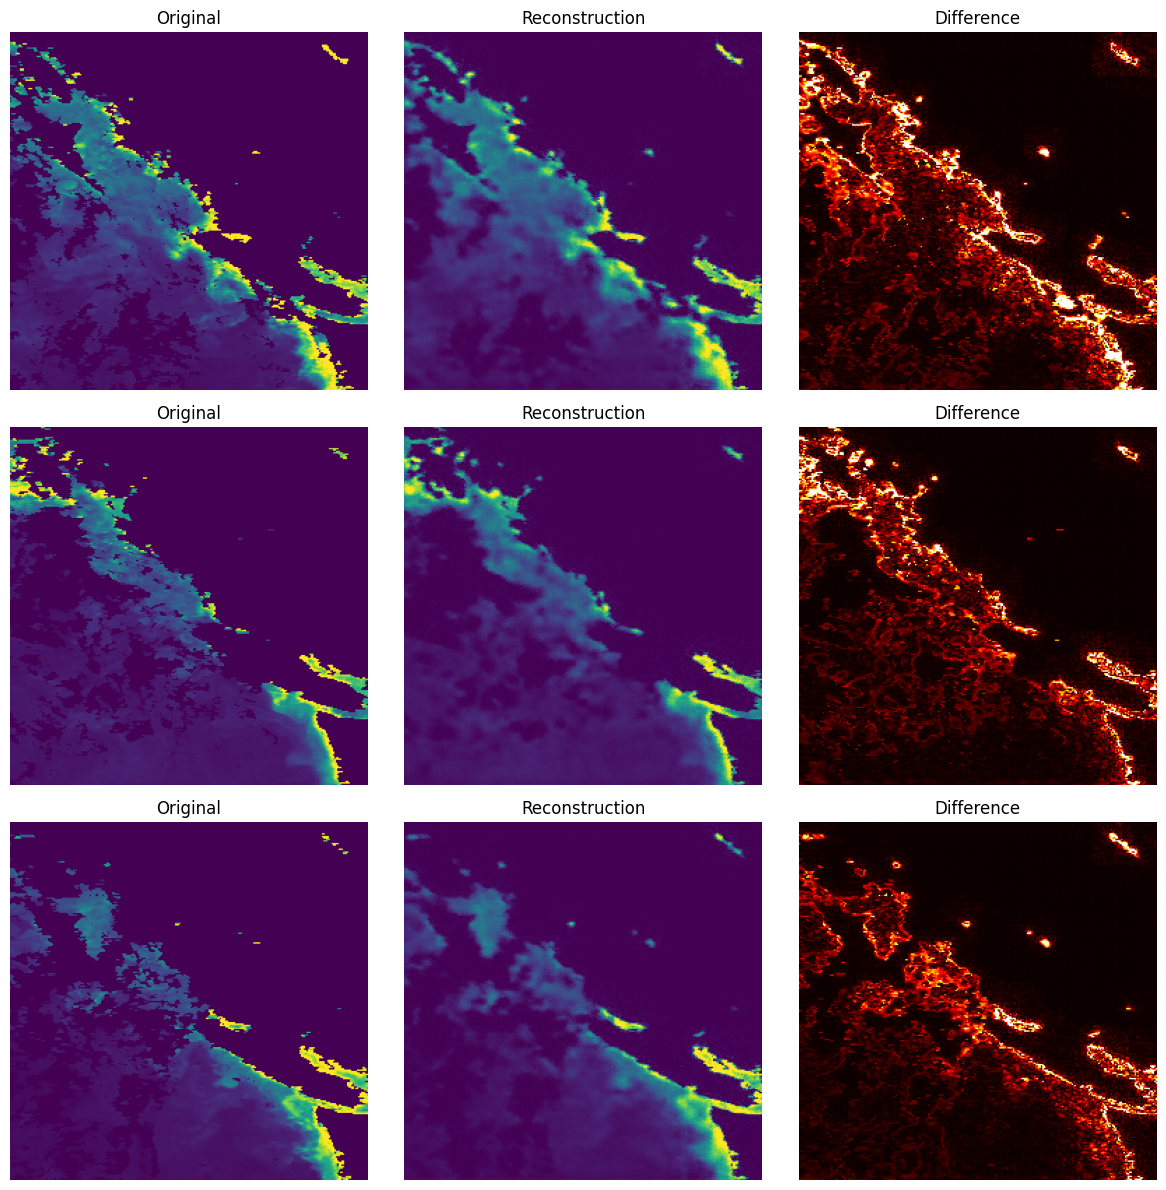

In [18]:
processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed"
model_weights_file = "/content/APS360_Project/CAE_model.pth"

if not os.path.exists(processed_dir):
  print ("Directory not found")
  exit()

dataset = Dataload(processed_dir)

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

model, imgs = setup_inference(model_weights_file, dataloader)

recons, diff_maps = calculate_difference_map(model, imgs)

plot_triplets(imgs, recons, diff_maps, 3)

In [37]:
def setup_eval_environment(model_path, processed_dir):
    model = Autoencoder()

    # load model weights
    model.load_state_dict(torch.load(model_path, weights_only=True))

    model.eval() # set model to eval mode

    dataset = Dataload(processed_dir)

    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    return model, dataloader

def calculate_all_losses(model, dataloader, pixel_threshold=0.5):
    criterion = nn.MSELoss()

    model.eval()

    all_losses = []

    # get MSE loss for each image and reconstruction from model
    with torch.no_grad():
        for data in dataloader:
            imgs, _ = data
            recons = model(imgs)

            mask = (imgs > 0.0).float()
            sq_diff = (recons - imgs) ** 2
            masked_sq_diff = sq_diff * mask

            anomalous_pixels = (masked_sq_diff > pixel_threshold).float()
            valid_pixels = mask.sum() + 1e-8
            anomaly_percentage = (anomalous_pixels.sum() / valid_pixels) * 100
            all_losses.append(anomaly_percentage.item())
            #loss = criterion (imgs, recons)
            #all_losses.append(loss.item())

    return all_losses

def find_threshold(losses_list, percentile=95):
    losses_np = np.array(losses_list)

    threshold = np.percentile(losses_np, 95)

    return threshold

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import os

from autoencoder import Autoencoder
from data_loader import Dataload

In [38]:
model, dataloader = setup_eval_environment(model_weights_file, processed_dir)

losses = calculate_all_losses(model, dataloader)

threshold = find_threshold(losses)

print ("Calculated threshold:", threshold)
print (np.array(losses))

Calculated threshold: 2.669219970703125
[3.24401855e+00 1.83105469e+00 1.15509033e+00 1.41601562e+00
 1.77764893e+00 1.88751221e+00 2.01263428e+00 2.41241455e+00
 0.00000000e+00 1.57775879e+00 2.25372314e+00 1.82800293e+00
 1.02081299e+00 2.41546631e+00 1.09100342e+00 2.08129883e+00
 7.93457031e-02 2.49328613e+00 2.95410156e+00 2.13928223e+00
 4.60815430e-01 1.62963867e+00 3.03649902e-01 6.71386719e-01
 0.00000000e+00 2.77557373e+00 2.11029053e+00 2.16674805e-01
 1.82037354e+00 1.69830322e+00 3.90625000e-01 0.00000000e+00
 2.04010010e+00 9.17053223e-01 2.21557617e+00 1.07879639e+00
 2.24761963e+00 2.72216797e+00 1.26647949e-01 3.34777832e+00
 7.67517090e-01 1.62200928e+00 2.67181396e+00 1.97601318e+00
 2.25982666e+00 1.91802979e+00 1.96228027e+00 7.33947754e-01
 2.74658203e-02 0.00000000e+00 5.34057617e-01 8.34655762e-01
 1.21917725e+00 0.00000000e+00 1.91040039e+00 0.00000000e+00
 1.99890137e-01 1.16882324e+00 1.80969238e+00 1.52587891e-03
 1.43432617e-01 7.96508789e-01 1.81274414e+00

In [39]:
processed_blob_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_blob_data"

model, dataloader = setup_eval_environment(model_weights_file, processed_blob_dir)

blob_losses = calculate_all_losses(model, dataloader)

print (np.array(blob_losses))

[1.26647949 1.98059082 1.19934082 1.33209229 1.81121826 2.8213501
 2.24914551 1.90429688 2.03704834 1.45263672 0.         2.15606689
 0.45623779 1.74560547 0.30822754 2.04315186 1.4755249  1.31225586
 2.4887085  1.30767822 1.00250244 2.47344971 1.8737793  0.00610352
 0.         0.         2.29644775 1.98669434 2.44903564 1.85546875
 1.54418945 1.95922852 0.12054443 1.92565918 0.34484863 1.62811279
 0.84381104 2.94476485 1.69067383 2.15911865 1.27258301 2.56652832
 1.13830566 2.40936279 0.54626465 1.87988281 1.3381958  1.85394287
 1.07116699 0.31585693 0.         0.9262085  0.90484619 0.16326904
 1.0055542  0.36621094 2.08129883 2.39562988 1.7578125  0.70037842
 2.21710205 0.04730225 1.78070068 1.93328857 0.53863525 2.04315186
 1.35345459 1.39160156 0.37841797 0.51422119 1.10931396]
